# Week 2 Data Download

Run this notebook once to download example audio data.

After that, run:

SIP_Week2_template.ipynb

## 1. Environment Check

In [1]:
import torch
import torchaudio
import librosa

print("Environment is working correctly!")

Environment is working correctly!


## 2. Download YESNO Dataset

We now download a small speech dataset to use in Week 2 experiments.

In [2]:
import os

data_path = "../data"
os.makedirs(data_path, exist_ok=True)

print("Created:", os.path.abspath(data_path))

Created: /Users/tmatsui/Dropbox/SLAI/SIP/data


In [3]:
from torchaudio.datasets import YESNO

dataset = YESNO(root="../data", download=True)

print("Number of samples:", len(dataset))

Number of samples: 60


## Step 1 — Locate the YESNO WAV File

We first retrieve the file path of one YESNO sample.

The YESNO dataset stores labels in the filename itself.
For example:

0_0_0_0_1_1_1_1.wav

Each digit represents a spoken word:
0 = "no"
1 = "yes"

This step confirms:
- The dataset is properly downloaded
- The file structure is accessible
- We can identify one concrete WAV file for analysis

In [4]:
import os
from torchaudio.datasets import YESNO

# We keep using the YESNO dataset object for file listing / labels.
# Note: root points to your SIP/data folder (one level above notebooks).
root = "../data"
ds = YESNO(root=root, download=False)

# YESNO stores file IDs internally; we build the WAV path from them.
wav_path = os.path.join(ds._path, ds._walker[0] + ".wav")
print("WAV path:", wav_path)

WAV path: ../data/waves_yesno/0_0_0_0_1_1_1_1.wav


## Step 2 — Load the Audio with librosa

We load the WAV file using librosa instead of torchaudio.

Why librosa?
- It does not require TorchCodec or FFmpeg.
- It provides stable and simple audio decoding.

We load:
- y : waveform (1D numpy array)
- sr : sampling rate

We also print:
- Number of samples
- Duration in seconds
- Amplitude range (min/max)

This verifies that the audio signal is valid.

In [5]:
import librosa
import numpy as np

# Load as mono and keep the original sampling rate (sr=None).
y, sr = librosa.load("../data/waves_yesno/0_0_0_0_1_1_1_1.wav", sr=None, mono=True)

print("Sample rate:", sr)
print("Num samples:", len(y))
print("Duration (sec):", len(y) / sr)
print("Min/Max:", float(np.min(y)), float(np.max(y)))

Sample rate: 8000
Num samples: 50800
Duration (sec): 6.35
Min/Max: -0.282012939453125 0.3204345703125


## Step 3 — Plot the Waveform

We visualize the waveform in the time domain.

Why plot the waveform?
- To check signal integrity
- To detect clipping or distortion
- To understand temporal structure

We plot only the first 1.5 seconds for readability.

This corresponds to the time-domain view of the speech signal.

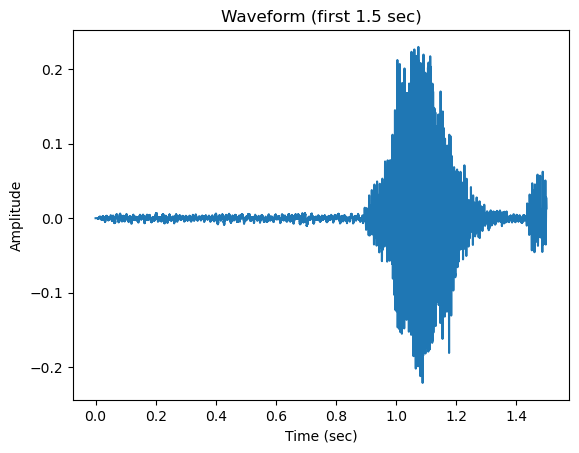

In [6]:
import matplotlib.pyplot as plt

# Plot a short segment for readability (first 1.5 seconds).
t = np.arange(len(y)) / sr
max_sec = 1.5
idx = int(max_sec * sr)

plt.figure()
plt.plot(t[:idx], y[:idx])
plt.xlabel("Time (sec)")
plt.ylabel("Amplitude")
plt.title("Waveform (first 1.5 sec)")
plt.show()

## Step 4 — Compute and Visualize the STFT Spectrogram

We now compute the Short-Time Fourier Transform (STFT).

Parameters:
- Window length: 25 ms
- Hop size: 10 ms
- Window type: Hann
- n_fft: 512

Pipeline:
1. Compute complex STFT
2. Take magnitude
3. Convert to decibels (dB)
4. Visualize the spectrogram

This gives us the time–frequency representation,
which is the foundation for:

STFT → Mel → log → DCT

The spectrogram reveals:
- Formant structure
- Harmonics
- Noise components
- Temporal variation

This is the starting point for log-Mel and MFCC features.

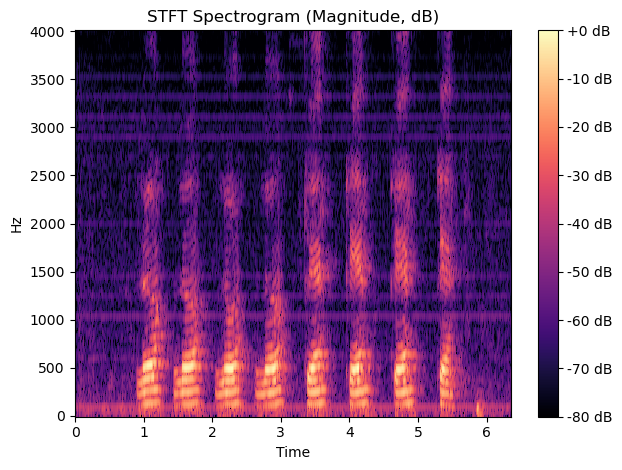

In [7]:
import librosa.display

# Standard speech defaults (Week 1/2):
# 25 ms window, 10 ms hop, and n_fft >= window length in samples.
n_fft = 512
win_length = int(0.025 * sr)   # 25 ms
hop_length = int(0.010 * sr)   # 10 ms

# Compute complex STFT: shape (freq_bins, frames)
D = librosa.stft(y, n_fft=n_fft, win_length=win_length, hop_length=hop_length, window="hann")

# Convert to magnitude and then to dB
S = np.abs(D)
S_db = librosa.amplitude_to_db(S, ref=np.max)

plt.figure()
librosa.display.specshow(S_db, sr=sr, hop_length=hop_length, x_axis="time", y_axis="hz")
plt.colorbar(format="%+2.0f dB")
plt.title("STFT Spectrogram (Magnitude, dB)")
plt.tight_layout()
plt.show()

# LibriSpeech → STFT Spectrogram (TorchCodec-free)

**Important note:** We will NOT call `dataset[0]` because it triggers `torchaudio.load()`,
which may require TorchCodec/FFmpeg.

Instead, we:
1. Download LibriSpeech
2. Read metadata only (no audio decoding)
3. Construct the path to one `.flac` file
4. Load audio using `librosa` (stable decoding)
5. Compute STFT and plot the spectrogram

In [8]:
from torchaudio.datasets import LIBRISPEECH

root = "../data"
subset = "test-clean"   # small and standard
dataset_ls = LIBRISPEECH(root=root, url=subset, download=True)

print("Number of items (metadata entries):", len(dataset_ls))

Number of items (metadata entries): 2620


## Step A — Get metadata (without loading waveform)

We use `get_metadata(i)` to retrieve:
- relative audio path (inside the dataset folder)
- sample rate (expected)
- transcript
- speaker / chapter / utterance IDs

This avoids calling `torchaudio.load()`.

In [9]:
meta = dataset_ls.get_metadata(0)

rel_path = meta[0]          # relative path to audio file
sr_expected = meta[1]       # expected sample rate
transcript = meta[2]
speaker_id = meta[3]
chapter_id = meta[4]
utterance_id = meta[5]

print("Relative path:", rel_path)
print("Expected sr:", sr_expected)
print("Transcript:", transcript[:100], "...")
print("IDs:", speaker_id, chapter_id, utterance_id)

Relative path: test-clean/1089/134686/1089-134686-0000.flac
Expected sr: 16000
Transcript: HE HOPED THERE WOULD BE STEW FOR DINNER TURNIPS AND CARROTS AND BRUISED POTATOES AND FAT MUTTON PIEC ...
IDs: 1089 134686 0


## Step B — Load audio with librosa

We load the `.flac` file with `librosa` (not torchaudio).
This typically works without TorchCodec.

In [10]:
import os
import librosa
import numpy as np

audio_path = os.path.join(dataset_ls._archive, rel_path)  # absolute path inside LibriSpeech folder
print("Audio file:", audio_path)

# Load as mono, keep original sampling rate
y, sr = librosa.load(audio_path, sr=None, mono=True)

print("Loaded sr:", sr)
print("Duration (sec):", len(y) / sr)
print("Min/Max:", float(np.min(y)), float(np.max(y)))

Audio file: ../data/LibriSpeech/test-clean/1089/134686/1089-134686-0000.flac
Loaded sr: 16000
Duration (sec): 10.435
Min/Max: -0.467071533203125 0.653411865234375


## Step C — Compute STFT and plot spectrogram

We use standard speech defaults:
- window length: 25 ms
- hop length: 10 ms
- n_fft: 512
- window: Hann

Then we plot the magnitude spectrogram in dB.

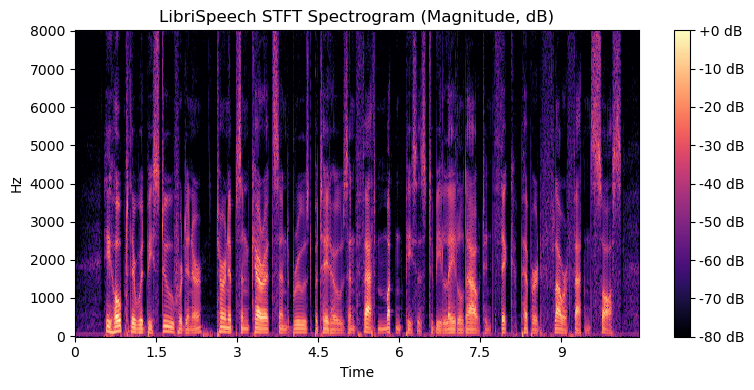

In [11]:
import matplotlib.pyplot as plt
import librosa.display

n_fft = 512
win_length = int(0.025 * sr)   # 25 ms
hop_length = int(0.010 * sr)   # 10 ms

D = librosa.stft(y, n_fft=n_fft, win_length=win_length, hop_length=hop_length, window="hann")
S = np.abs(D)
S_db = librosa.amplitude_to_db(S, ref=np.max)

plt.figure(figsize=(8, 4))
librosa.display.specshow(S_db, sr=sr, hop_length=hop_length, x_axis="time", y_axis="hz")
plt.colorbar(format="%+2.0f dB")
plt.title("LibriSpeech STFT Spectrogram (Magnitude, dB)")
plt.tight_layout()
plt.show()

## Listen to the Speech Sample

We use IPython's Audio widget to play the waveform.

This allows us to:
- Verify that the audio was loaded correctly
- Check for noise or distortion
- Relate what we hear to the spectrogram

In [12]:
from IPython.display import Audio

# Play the full signal
Audio(y, rate=sr)

In [13]:
duration_sec = 3
Audio(y[:int(duration_sec * sr)], rate=sr)